<a href="https://colab.research.google.com/github/Dorcasi/hands-on-python-3084712/blob/main/Compiled_strains_Average_Permeability_Sample_D4H_xlsx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

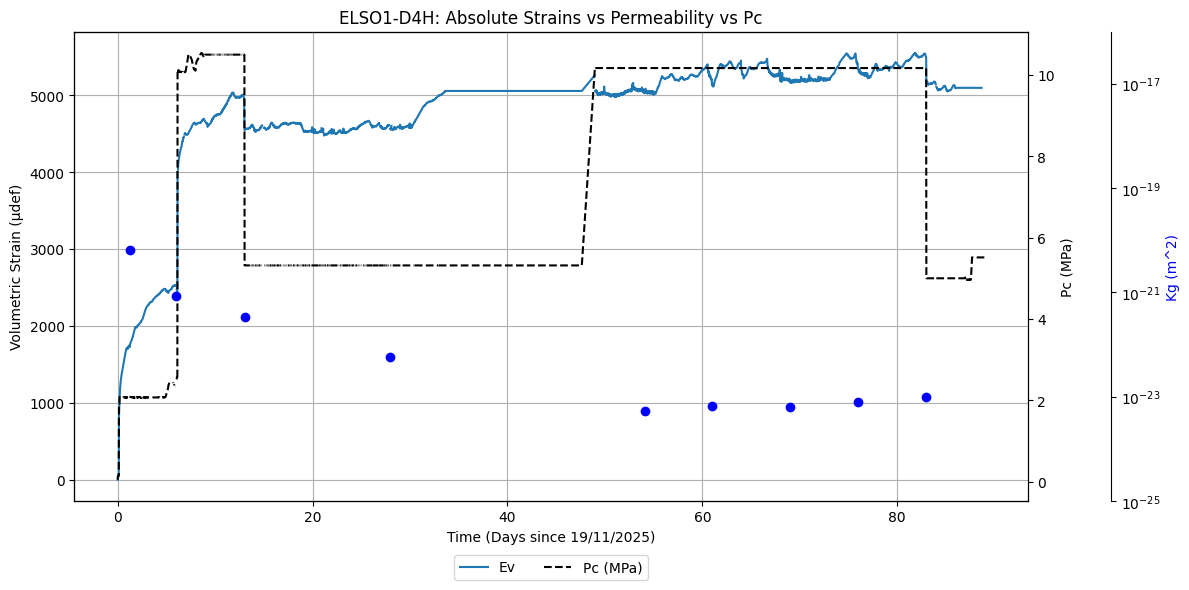

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D4H_copy.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)", "Ev"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D4H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Ev"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel("Time (Days since 19/11/2025)")
ax1.set_ylabel("Volumetric Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle= '', label="Kg (m^2)") # Changed linestyle to empty string
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-25, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2 ,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

In [ ]:
l

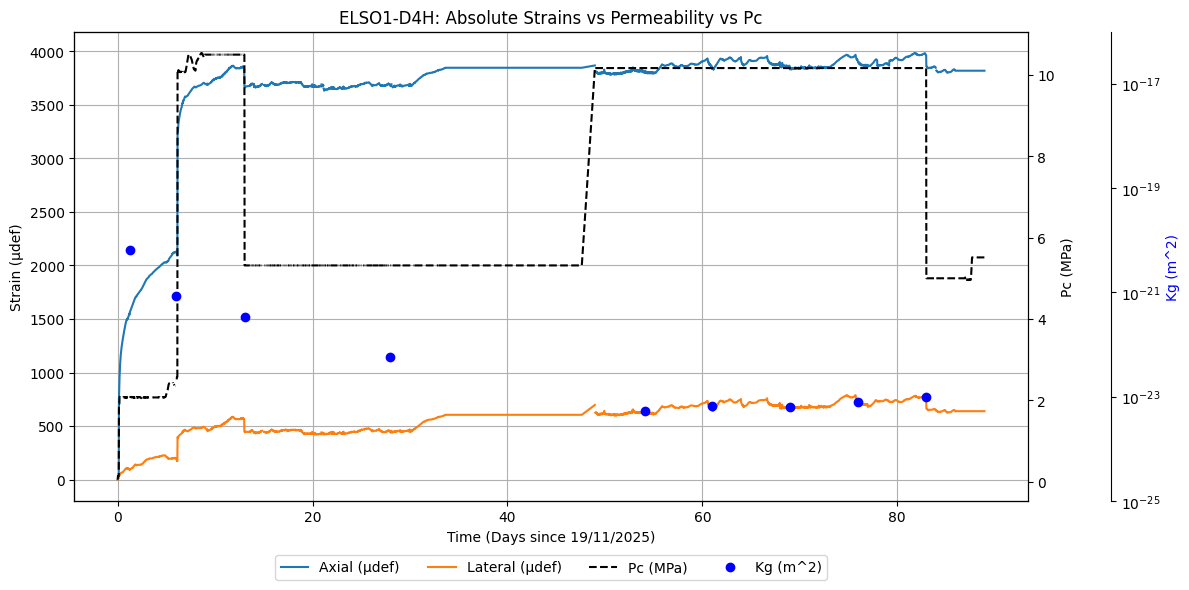

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D4H_copy.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)", "Ev"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D4H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Ev data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel("Time (Days since 19/11/2025)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle= '', label="Kg (m^2)") # Changed linestyle to empty string
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-25, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

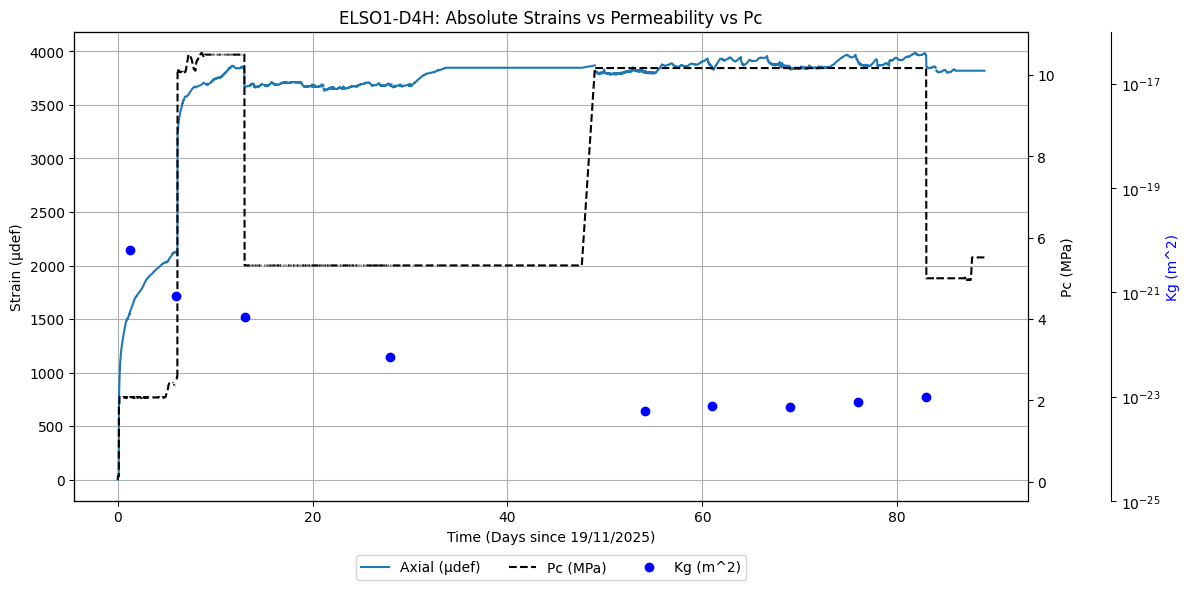

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D4H_copy.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)", "Ev"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D4H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Ev data
for col in ["Axial (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel("Time (Days since 19/11/2025)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle= '', label="Kg (m^2)") # Changed linestyle to empty string
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-25, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_D4H_copy.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_D4H.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in [ "Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel("Time (Days since 19/11/2025)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle= '', label="Kg (m^2)") # Changed linestyle to empty string
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-25, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

ValueError: Length mismatch: Expected axis has 5 elements, new values have 4 elements

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS AND K----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_Sample_XD-1.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_Sample_XD-1.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel("Time (Days since 19/11/2025)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
         color="blue", marker="o", linestyle="-", label="Kg (m^2)")
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-25, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Absolute Strains vs Permeability vs Pc") # Update title here
plt.tight_layout()
plt.show()

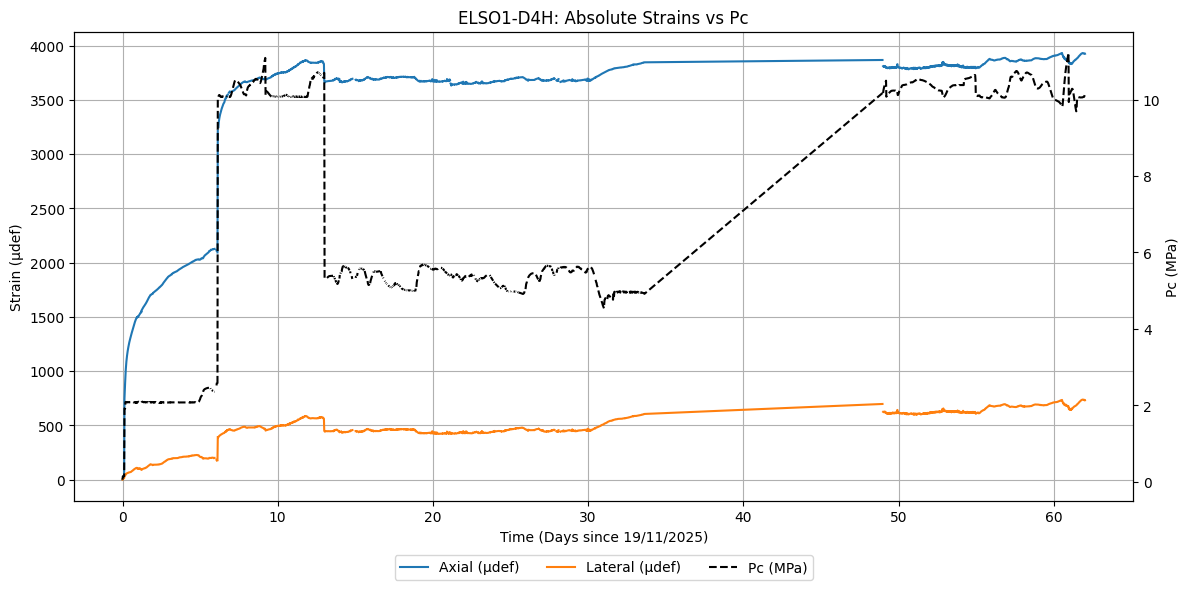

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ---------- ABSOLUTE VALUED STRAINS----------------

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_Sample_XD-1.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_Sample_XD-1.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Calculate days since start ----------
# Find the earliest date across both dataframes
start_date = min(df1_resampled.index.min(), df2.index.min())

# Calculate days since start as fractional days
df1_resampled['days_since_start'] = (df1_resampled.index - start_date).total_seconds() / (24 * 3600)
df2['days_since_start'] = (df2.index - start_date).total_seconds() / (24 * 3600)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled['days_since_start'], df1_resampled[col].abs(), label=col) # Apply .abs() here

ax1.set_xlabel("Time (Days since 19/11/2025)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled['days_since_start'], df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis (Permeability) removed as per user request
# ax3 = ax1.twinx()
# ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
# ax3.plot(df2['days_since_start'], df2["Kg (m^2)"],
#          color="blue", marker="o", linestyle="-", label="Kg (m^2)")
# ax3.set_ylabel("Kg (m^2)", color="blue")
# ax3.set_yscale('log') # Set y-axis to logarithmic scale
# ax3.set_ylim(1e-22, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# lines3, labels3 = ax3.get_legend_handles_labels() # Removed permeability from legend
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Remove datetime formatting for x-axis as it's now days
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Absolute Strains vs Pc") # Updated title
plt.tight_layout()
plt.show()

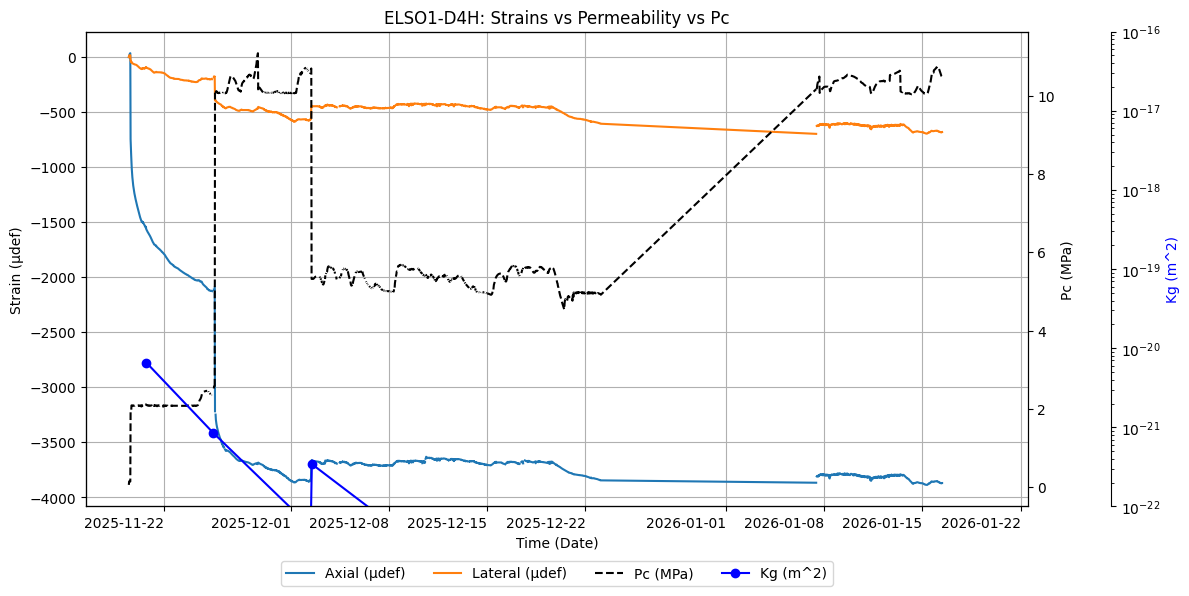

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- Load first dataset (resampled gauges + P_conf) ----------
file1 = "/content/Compiled_strains_Average_Sample_XD-1.xlsx" # <-- file path/name
df1 = pd.read_excel(file1)

df1.columns = ["Time (Date)", "Pc (MPa)", "Axial (µdef)", "Lateral (µdef)"]

df1["Time (Date)"] = pd.to_datetime(df1["Time (Date)"], dayfirst=True)
df1.set_index("Time (Date)", inplace=True)

# Resample every 30 minutes aligned with first timestamp of each day
df1_resampled = df1.groupby(df1.index.date).apply(lambda g: g.resample("30min", origin=g.index.min()).first())
df1_resampled.index = df1_resampled.index.droplevel(0)

# ---------- Load second dataset (no resampling) ----------
file2 = "/content/Permeability_Sample_XD-1.xlsx" # <-- filename
df2 = pd.read_excel(file2)

df2.columns = ["Date/Time", "Kg (m^2)"]
df2["Date/Time"] = pd.to_datetime(df2["Date/Time"], dayfirst=True)
df2.set_index("Date/Time", inplace=True)

# ---------- Plot ----------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: Jauge data
for col in ["Axial (µdef)", "Lateral (µdef)"]:
    ax1.plot(df1_resampled.index, df1_resampled[col], label=col)

ax1.set_xlabel("Time (Date)")
ax1.set_ylabel("Strain (µdef)")
ax1.grid(True)

# Secondary axis: P_conf
ax2 = ax1.twinx()
ax2.plot(df1_resampled.index, df1_resampled["Pc (MPa)"],
         color="black", linestyle="--", label="Pc (MPa)")
ax2.set_ylabel("Pc (MPa)")

# Third axis: Kg (m^2) â€” offset on the right
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60)) # shift outward by 60px
ax3.plot(df2.index, df2["Kg (m^2)"],
         color="blue", marker="o", linestyle="-", label="Kg (m^2)")
ax3.set_ylabel("Kg (m^2)", color="blue")
ax3.set_yscale('log') # Set y-axis to logarithmic scale
ax3.set_ylim(1e-24, 1e-16) # Set the logarithmic y-axis limits

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=True)

# Format x-axis datetime labels
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate(rotation=0)

plt.title("ELSO1-D4H: Strains vs Permeability vs Pc")
plt.tight_layout()
plt.show()